### **This notebook contains the sentiment analysis of the Text data (reviews) from the Twitter dataset. The dataset contains the tweets and their corresponding sentiment labels  . The analysis includes data preprocessing, feature engineering, using nlp, machine learning models, and evaluating the performance of the models. The goal is to classify the sentiment of the tweets as positive, negative, or neutral.**

In [1]:
# Importing specific libraries for data manipulation, visualization, and machine learning

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon', quiet=True)

True

In [2]:
# Loading the dataset

data = pd.read_csv('Twitter_Data.csv')
data.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [3]:
# Making the copy of the dataset to avoid any changes in the original dataset

df = data.copy()
df['clean_text'].value_counts()

clean_text
when modi promised “minimum government maximum governance” expected him begin the difficult job reforming the state why does take years get justice state should and not business and should exit psus and temples                                          1
talk all the nonsense and continue all the drama will vote for modi                                                                                                                                                                                         1
what did just say vote for modi  welcome bjp told you rahul the main campaigner for modi think modi should just relax                                                                                                                                       1
asking his supporters prefix chowkidar their names modi did great service now there confusion what read what not now crustal clear what will crass filthy nonsensical see how most abuses are coming from chowkidars               

- Now let's start with the data preprocessing steps, which include cleaning the text data, removing stop words, and performing tokenization. After that, we will move on to feature engineering using techniques like TF-IDF and word embeddings.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


- - As we can see, the column 'clean_text' contains the cleaned version of the original text data. We will use this column for our analysis and modeling. The value counts of this column show the distribution of unique cleaned text entries in the dataset.

In [5]:
# Now we can use the VADER sentiment analyzer to analyze the sentiment of the cleaned text data.
# We will create a new column in the dataframe to store the sentiment scores.

sia = SentimentIntensityAnalyzer()

def get_sentiment_metrics(text):
    # Handle missing values
    if pd.isna(text):
        return pd.Series({'sentiment_score': 0.0, 'sentiment_category': 'Neutral'})
    
    # polarity_scores returns a dict: {'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0}
    scores = sia.polarity_scores(text)
    
    # Categorize based on the standard compound score thresholds
    # Greater than or equal to 0.05 = Positive, Less than or equal to -0.05 = Negative
    if scores['compound'] >= 0.05:
        category = 'Positive'
    elif scores['compound'] <= -0.05:
        category = 'Negative'
    else:
        category = 'Neutral'
        
    return pd.Series({'sentiment_score': scores['compound'], 'sentiment_category': category})

# Apply sentiment analysis to the cleaned text
sentiment_df = df['clean_text'].apply(get_sentiment_metrics)
df[['sentiment_score', 'sentiment_category']] = sentiment_df[['sentiment_score', 'sentiment_category']]

In [6]:
df.head()

,clean_text,category,sentiment_score,sentiment_category
0,when modi promised “minimum government maximum...,-1.0,0.5267,Positive
1,talk all the nonsense and continue all the dra...,0.0,-0.4019,Negative
2,what did just say vote for modi welcome bjp t...,1.0,0.7096,Positive
3,asking his supporters prefix chowkidar their n...,1.0,-0.0713,Negative
4,answer who among these the most powerful world...,1.0,0.4754,Positive


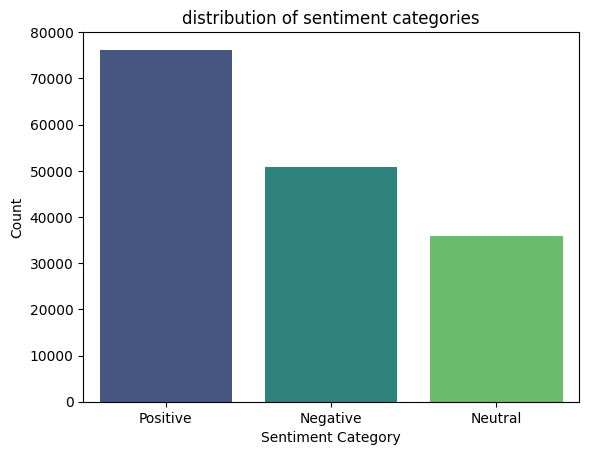

In [7]:
# Making the plot of the sentiment category distribution

plt.Figure(figsize=(10,6))
sns.countplot(x='sentiment_category', data=df, palette='viridis', hue='sentiment_category')
plt.title('distribution of sentiment categories')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.show()

- So here we can see that there are more number of positive reviews than the negative reviews in the dataset. This indicates that the dataset is imbalanced, which may affect the performance of our machine learning models. We will need to consider this imbalance when training our models and evaluating their performance.

In [8]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Now making a BOW and TF-IDF vectorization of the cleaned text data for machine learning model training.
# First, handle missing values by replacing NaN with empty strings
df['clean_text'] = df['clean_text'].fillna('')

bow_vectorizer = CountVectorizer(max_features=5000)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
bow_features = bow_vectorizer.fit_transform(df['clean_text'])
tfidf_features = tfidf_vectorizer.fit_transform(df['clean_text'])


### Train a sentiment classifier using the actual category labels
We have actual sentiment values in `category` (-1, 0, 1), so we can build a supervised model and compare it with the VADER baseline.

In [9]:
# Map numeric category labels to readable sentiment names
label_map = {-1.0: 'Negative', 0.0: 'Neutral', 1.0: 'Positive'}
df['label'] = df['category'].map(label_map).astype('category')

# Show actual distribution of the sentiment labels
print(df['label'].value_counts())

# Compare the VADER prediction with the actual labels if available
if 'sentiment_category' in df.columns:
    df['vader_match'] = df['label'] == df['sentiment_category']
    print('\nVADER agreement with actual labels: {:.2f}%'.format(df['vader_match'].mean() * 100))
    display(df[['clean_text', 'category', 'label', 'sentiment_category']].head())

label
Positive    72250
Neutral     55213
Negative    35510
Name: count, dtype: int64

VADER agreement with actual labels: 56.80%


,clean_text,category,label,sentiment_category
0,when modi promised “minimum government maximum...,-1.0,Negative,Positive
1,talk all the nonsense and continue all the dra...,0.0,Neutral,Negative
2,what did just say vote for modi welcome bjp t...,1.0,Positive,Positive
3,asking his supporters prefix chowkidar their n...,1.0,Positive,Negative
4,answer who among these the most powerful world...,1.0,Positive,Positive


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Remove rows with NaN values in category column
df_clean = df.dropna(subset=['category'])
tfidf_features_clean = tfidf_features[df_clean.index]

# Train/test split using TF-IDF features and the actual numeric category labels
X_train, X_test, y_train, y_test = train_test_split(
    tfidf_features_clean, df_clean['category'], test_size=0.2, random_state=42, stratify=df_clean['category']
)

model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Logistic Regression accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

conf_mat = confusion_matrix(y_test, y_pred, labels=[-1.0, 0.0, 1.0])
print('\nConfusion matrix:')
display(conf_mat)

Logistic Regression accuracy: 0.9262463568031907

Classification report:
              precision    recall  f1-score   support

    Negative       0.91      0.82      0.87      7102
     Neutral       0.92      0.98      0.95     11043
    Positive       0.94      0.93      0.94     14450

    accuracy                           0.93     32595
   macro avg       0.92      0.91      0.92     32595
weighted avg       0.93      0.93      0.93     32595


Confusion matrix:


array([[ 5858,   520,   724],
       [   76, 10827,   140],
       [  472,   472, 13506]])

In [11]:
from sklearn.svm import LinearSVC

# Train a Linear SVM model using the same TF-IDF features
svm_model = LinearSVC(random_state=42, max_iter=5000)
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print('Linear SVM accuracy:', accuracy_score(y_test, svm_pred))
print('\nSVM classification report:')
print(classification_report(y_test, svm_pred, target_names=['Negative', 'Neutral', 'Positive']))

svm_conf_mat = confusion_matrix(y_test, svm_pred, labels=[-1.0, 0.0, 1.0])
print('\nSVM confusion matrix:')
print(svm_conf_mat)

Linear SVM accuracy: 0.9430587513422304

SVM classification report:
              precision    recall  f1-score   support

    Negative       0.92      0.87      0.90      7102
     Neutral       0.95      0.98      0.96     11043
    Positive       0.95      0.95      0.95     14450

    accuracy                           0.94     32595
   macro avg       0.94      0.93      0.94     32595
weighted avg       0.94      0.94      0.94     32595


SVM confusion matrix:
[[ 6201   294   607]
 [   85 10831   127]
 [  434   309 13707]]


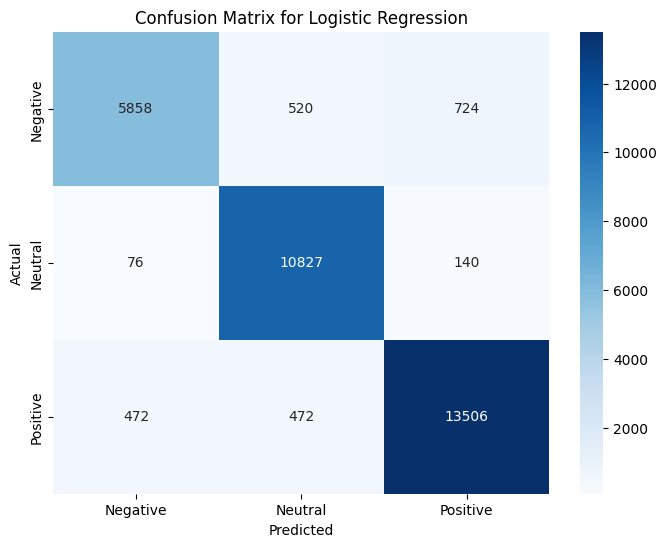

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

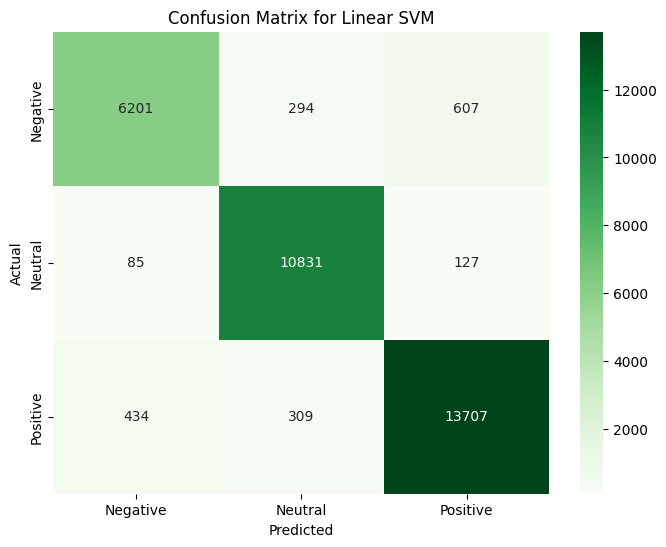

In [13]:
# Confusion matrix for SVM 

plt.figure(figsize=(8, 6))
sns.heatmap(svm_conf_mat, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Linear SVM')
plt.show()

### Compare the performance of the trained model with the VADER baseline

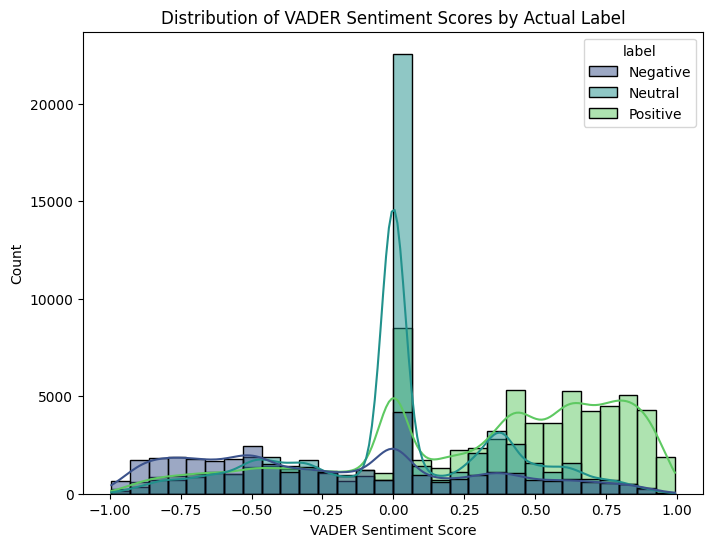

In [14]:
# Comparison for other models

plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='sentiment_score', hue='label', bins=30, kde=True, palette='viridis')
plt.title('Distribution of VADER Sentiment Scores by Actual Label')
plt.xlabel('VADER Sentiment Score')
plt.ylabel('Count')
plt.show()

# Sentiment Analysis on Twitter Data

## Project Overview
This project focuses on performing **Sentiment Analysis on Twitter data** using **Natural Language Processing (NLP)** and **Machine Learning** techniques. The primary objective is to classify tweets into **Positive, Neutral, and Negative sentiments**.

---

## Dataset Information
- **Dataset Used:** Twitter Tweets Dataset
- **Total Records:** 162,980 tweets
- **Target Labels:**
  - `1` → Positive
  - `0` → Neutral
  - `-1` → Negative

### Dataset Distribution
| Sentiment | Count |
|----------|-------|
| Positive | 72,250 |
| Neutral | 55,213 |
| Negative | 35,510 |

The dataset is slightly imbalanced, with positive tweets appearing more frequently than negative tweets.

---

## Data Preprocessing
Several preprocessing techniques were applied to clean and prepare the text data:

- Handling missing values
- Removing unnecessary characters and symbols
- Cleaning tweet text
- Converting text into numerical format using:
  - **Bag of Words (BoW)**
  - **TF-IDF Vectorization**

---

## Sentiment Analysis Approaches

### 1. VADER Sentiment Analyzer
A lexicon-based sentiment analysis method using NLTK’s VADER was implemented to generate:
- Sentiment polarity scores
- Predicted sentiment labels

### 2. Machine Learning Models
The following supervised learning models were trained using TF-IDF features:

- **Logistic Regression**
- **Linear Support Vector Machine (Linear SVM)**

---

## Model Performance

### Logistic Regression
- **Accuracy:** 92.62%
- Achieved strong precision and recall values.

### Linear SVM
- **Accuracy:** 94.30%
- Best performing model in the project.
- Outperformed Logistic Regression in overall classification accuracy.

---

## Key Findings
- VADER sentiment analysis achieved approximately **56.8% agreement** with actual sentiment labels.
- Machine Learning models significantly improved prediction performance.
- **Linear SVM combined with TF-IDF vectorization produced the highest accuracy.**
- TF-IDF proved to be highly effective for tweet sentiment classification.

---

## Visualizations Included
The project also includes:
- Sentiment distribution graphs
- Confusion matrices
- Histogram analysis of sentiment scores

---

## Conclusion
This project successfully demonstrates the application of **Natural Language Processing (NLP)** and **Machine Learning** for real-world Twitter sentiment analysis. Among all methods tested, the **Linear SVM model with TF-IDF vectorization achieved the best performance**, making it the most effective model for sentiment classification in this analysis.